# 01211373 : Machine Learning and Programming for Industry

## Lecture 09A : Neural Networks and Deep Learning

**Topic :**

* The Mechanics of PyTorch

**Note :** 

this notebook contains selected materials from chapter 13 of [1], with code from accompanying notebook.


## The key features of PyTorch

### PyTorch's computational graphs

PyTorch performs its computations based on a directed acyclic graph (DAG). In this section, we will
see how these graphs can be defined for a simple arithmetic computation. Then, we will see the dynamic
graph paradigm, as well as how the graph is created on the fly in PyTorch.

#### Understanding computation graphs

PyTorch relies on building a computation graph at its core, and it uses this computation graph to
derive relationships between tensors from the input all the way to the output. Let’s say that we have
rank 0 (scalar) tensors $a, b,$ and $c$ and we want to evaluate $z = 2 \times (a – b) + c$. This evaluation can be represented as a computation graph, as shown in Figure 13.1

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch13/figures/13_01.png" width=600 />

Figure 13.1 How a computation graph works

As you can see, the computation graph is simply a network of nodes. Each node resembles an operation,
which applies a function to its input tensor or tensors and returns zero or more tensors as the
output. PyTorch builds this computation graph and uses it to compute the gradients accordingly. In the
next subsection, we will see some examples of creating a graph for this computation using PyTorch.

#### Creating a graph in PyTorch

Let’s look at a simple example that illustrates how to create a graph in PyTorch for evaluating
$z = 2 \times (a – b) + c$, as shown in the previous figure. The variables $a, b,$ and $c$ are scalars (single numbers),
and we define these as PyTorch tensors. To create the graph, we can simply define a regular Python
function with $a, b, c$ as its input arguments, for example


In [2]:
import torch

In [3]:
def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(r1, 2)
    z = torch.add(r2, c)
    return z



Now, to carry out the computation, we can simply call this function with tensor objects as function
arguments. Note that PyTorch functions such as add, sub (or subtract), and mul (or multiply) also
allow us to provide inputs of higher ranks in the form of a PyTorch tensor object. In the following code
example, we provide scalar inputs (rank 0), as well as rank 1 and rank 2 inputs, as lists

In [4]:
print('Scalar Inputs:', compute_z(torch.tensor(1), torch.tensor(2), torch.tensor(3)))
print('Rank 1 Inputs:', compute_z(torch.tensor([1]), torch.tensor([2]), torch.tensor([3])))
print('Rank 2 Inputs:', compute_z(torch.tensor([[1]]), torch.tensor([[2]]), torch.tensor([[3]])))

Scalar Inputs: tensor(1)
Rank 1 Inputs: tensor([1])
Rank 2 Inputs: tensor([[1]])


In this section, you saw how simple it is to create a computation graph in PyTorch. Next, we will look
at PyTorch tensors that can be used for storing and updating model parameters.

#### PyTorch tensor objects for storing and updating model parameters

We covered tensor objects in Chapter 12, Parallelizing Neural Network Training with PyTorch. In PyTorch,
a special tensor object for which gradients need to be computed allows us to store and update the parameters
of our models during training. Such a tensor can be created by just assigning requires_grad
to True on user-specified initial values. Note that as of now (mid-2021), only tensors of floating point
and complex dtype can require gradients. In the following code, we will generate tensor objects of
type float32

In [5]:
a = torch.tensor(3.14, requires_grad=True)
b = torch.tensor([1.0, 2.0, 3.0], requires_grad=True) 
print(a)
print(b)

tensor(3.1400, requires_grad=True)
tensor([1., 2., 3.], requires_grad=True)


Notice that requires_grad is set to False by default. This value can be efficiently set to True by running
requires_grad_().

<span style="background-color: #e0e0e0">
method_() is an in-place method in PyTorch that is used for operations without making
a copy of the input.
</span>

Let’s take a look at the following example

In [6]:
w = torch.tensor([1.0, 2.0, 3.0])

print(w.requires_grad)

False


In [7]:
w.requires_grad_()

print(w.requires_grad)

True


You will recall that for NN models, initializing model parameters with random weights is necessary to
break the symmetry during backpropagation—otherwise, a multilayer NN would be no more useful
than a single-layer NN like logistic regression. When creating a PyTorch tensor, we can also use a
random initialization scheme. PyTorch can generate random numbers based on a variety of probability
distributions (see https://pytorch.org/docs/stable/torch.html#random-sampling). In the
following example, we will take a look at some standard initialization methods that are also available
in the torch.nn.init module (see https://pytorch.org/docs/stable/nn.init.html).

So, let’s look at how we can create a tensor with Glorot initialization, which is a classic random initialization
scheme that was proposed by Xavier Glorot and Yoshua Bengio. For this, we first create
an empty tensor and an operator called init as an object of class GlorotNormal. Then, we fill this
tensor with values according to the Glorot initialization by calling the xavier_normal_() method. In
the following example, we initialize a tensor of shape 2×3

In [8]:
import torch.nn as nn

torch.manual_seed(1)
w = torch.empty(2, 3)
nn.init.xavier_normal_(w)
print(w)

tensor([[ 0.4183,  0.1688,  0.0390],
        [ 0.3930, -0.2858, -0.1051]])


Read more about Xavier (or Glorot) initialization on p.414 of [1].

Now, to put this into the context of a more practical use case, let’s see how we can define two Tensor
objects inside the base nn.Module class

In [9]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = torch.empty(2, 3, requires_grad=True)
        nn.init.xavier_normal_(self.w1)
        self.w2 = torch.empty(1, 2, requires_grad=True)
        nn.init.xavier_normal_(self.w2)


These two tensors can be then used as weights whose gradients will be computed via automatic differentiation.

### Computing gradients via automatic differentiation

As you already know, optimizing NNs requires computing the gradients of the loss with respect to the
NN weights. This is required for optimization algorithms such as stochastic gradient descent (SGD).
In addition, gradients have other applications, such as diagnosing the network to find out why an NN
model is making a particular prediction for a test example. Therefore, in this section, we will cover
how to compute gradients of a computation with respect to its input variables.

#### Computing the gradients of the loss with respect to trainable variables

PyTorch supports automatic differentiation, which can be thought of as an implementation of the chain
rule for computing gradients of nested functions. Note that for the sake of simplicity, we will use the
term gradient to refer to both partial derivatives and gradients.

When we define a series of operations that results in some output or even intermediate tensors, PyTorch
provides a context for calculating gradients of these computed tensors with respect to its dependent
nodes in the computation graph. To compute these gradients, we can call the backward method from
the torch.autograd module. It computes the sum of gradients of the given tensor with regard to leaf
nodes (terminal nodes) in the graph.


Let’s work with a simple example where we will compute $z = wx + b$ and define the loss as the squared
loss between the target $y$ and prediction $z$, $Loss = (y – z)^2$. In the more general case, where we may have
multiple predictions and targets, we compute the loss as the sum of the squared error, $Loss = \sum_i (y_i - z_i)^2$
. In order to implement this computation in PyTorch, we will define the model parameters, $w$ and $b$,
as variables (tensors with the requires_gradient attribute set to True), and the input, $x$ and $y$, as
default tensors. We will compute the loss tensor and use it to compute the gradients of the model
parameters, $w$ and $b$, as follows


In [10]:
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True) 

x = torch.tensor([1.4])
y = torch.tensor([2.1])


z = torch.add(torch.mul(w, x), b)
 
loss = (y-z).pow(2).sum()
loss.backward()

print('dL/dw : ', w.grad)
print('dL/db : ', b.grad)


dL/dw :  tensor(-0.5600)
dL/db :  tensor(-0.4000)


Computing the value $z$ is a forward pass in an NN. We used the backward method on the loss tensor to compute $\frac{\partial Loss}{\partial w}$ and $\frac{\partial Loss}{\partial b}$. Since this is a very simple example, we can obtain $\frac{\partial Loss}{\partial w} = 2x(wx+b - y)$ 
symbolically to verify that the computed gradients match the results we obtained in the previous code example:

In [11]:
# verifying the computed gradient dL/dw
print(2  *x*((w * x + b) - y))

tensor([-0.5600], grad_fn=<MulBackward0>)


Similarly, you can verify that $\frac{\partial Loss}{\partial b} = 2(wx+b - y)$. 

In [12]:
# verifying the computed gradient dL/db
print(2*((w * x + b) - y))

tensor([-0.4000], grad_fn=<MulBackward0>)


#### Understanding automatic differentiation

Automatic differentiation represents a set of computational techniques for computing gradients of
arbitrary arithmetic operations. During this process, gradients of a computation (expressed as a series
of operations) are obtained by accumulating the gradients through repeated applications of the chain
rule. To better understand the concept behind automatic differentiation, let’s consider a series of
nested computations, $y = f(g(h(x)))$, with input $x$ and output $y$. This can be broken into a series of steps:

• $u_0 = x$

• $u_1 = h(x)$

• $u_2 = g(u_1)$

• $u_3 = f(u_2) = y$

The derivative $\frac{dy}{dx}$ can be computed in two different ways: forward accumulation, which starts with
$\frac{du_3}{dx}=\frac{du_3}{du_2}\frac{du_2}{du_0}$
, and reverse accumulation, which starts with $\frac{dy}{du_0}=\frac{dy}{du_1}\frac{du_1}{du_0}$
. Note that PyTorch uses the
latter, reverse accumulation, which is more efficient for implementing backpropagation.

#### Adversarial examples

Computing gradients of the loss with respect to the input example is used for generating adversarial
examples (or adversarial attacks). In computer vision, adversarial examples are examples that are
generated by adding some small, imperceptible noise (or perturbations) to the input example, which
results in a deep NN misclassifying them. Covering adversarial examples is beyond the scope of this
book, but if you are interested, you can find the original paper by Christian Szegedy et al., Intriguing
properties of neural networks at https://arxiv.org/pdf/1312.6199.pdf.



### Simplifying implementations of common architectures via the torch.nn module

You have already seen some examples of building a feedforward NN model (for instance, a multilayer
perceptron) and defining a sequence of layers using the nn.Module class. Before we take a deeper dive
into nn.Module, let’s briefly look at another approach for conjuring those layers via nn.Sequential.

#### Implementing models based on nn.Sequential

With nn.Sequential (https://pytorch.org/docs/master/generated/torch.nn.Sequential.html#sequential), the layers stored inside the model are connected in a cascaded way. In the following
example, we will build a model with two densely (fully) connected layers

In [13]:
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU()
)

model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

We specified the layers and instantiated the model after passing the layers to the nn.Sequential class.
The output of the first fully connected layer is used as the input to the first ReLU layer. The output of
the first ReLU layer becomes the input for the second fully connected layer. Finally, the output of the
second fully connected layer is used as the input to the second ReLU layer.

We can further configure these layers, for example, by applying different activation functions, initializers,
or regularization methods to the parameters. A comprehensive and complete list of available
options for most of these categories can be found in the official documentation:
    
• Choosing activation functions: https://pytorch.org/docs/stable/nn.html#non-linearactivations-weighted-sum-nonlinearity

• Initializing the layer parameters via nn.init: https://pytorch.org/docs/stable/nn.init.html

• Applying L2 regularization to the layer parameters (to prevent overfitting) via the parameter
weight_decay of some optimizers in torch.optim: https://pytorch.org/docs/stable/optim.html

• Applying L1 regularization to the layer parameters (to prevent overfitting) by adding the L1
penalty term to the loss tensor, which we will implement next

In the following code example, we will configure the first fully connected layer by specifying the
initial value distribution for the weight. Then, we will configure the second fully connected layer by
computing the L1 penalty term for the weight matrix    


In [14]:
nn.init.xavier_uniform_(model[0].weight)
 
l1_weight = 0.01
l1_penalty = l1_weight * model[2].weight.abs().sum()


Here, we initialized the weight of the first linear layer with Xavier initialization. And we computed
the L1 norm of the weight of the second linear layer.

Furthermore, we can also specify the type of optimizer and the loss function for training. Again, a
comprehensive list of all available options can be found in the official documentation:

• Optimizers via torch.optim: https://pytorch.org/docs/stable/optim.html#algorithms

• Loss functions: https://pytorch.org/docs/stable/nn.html#loss-functions

#### Choosing a loss function

Regarding the choices for optimization algorithms, SGD and Adam are the most widely used methods.
The choice of loss function depends on the task; for example, you might use mean square error loss
for a regression problem.

The family of cross-entropy loss functions supplies the possible choices for classification tasks, which
are extensively discussed in Chapter 14, Classifying Images with Deep Convolutional Neural Networks.

Furthermore, you can use the techniques you have learned from previous chapters (such as techniques
for model evaluation from Chapter 6, Learning Best Practices for Model Evaluation and Hyperparameter
Tuning) combined with the appropriate metrics for the problem. For example, precision and recall,
accuracy, area under the curve (AUC), and false negative and false positive scores are appropriate
metrics for evaluating classification models.

In this example, we will use the SGD optimizer, and cross-entropy loss for binary classification

In [15]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Next, we will look at a more practical example: solving the classic XOR classification problem. First,
we will use the nn.Sequential() class to build the model. Along the way, you will also learn about the
capacity of a model for handling nonlinear decision boundaries. Then, we will cover building a model
via nn.Module that will give us more flexibility and control over the layers of the network.

#### Solving an XOR classification problem

The XOR classification problem is a classic problem for analyzing the capacity of a model with regard
to capturing the nonlinear decision boundary between two classes. We generate a toy dataset of 200
training examples with two features (x0, x1) drawn from a uniform distribution between [–1, 1). Then,
we assign the ground truth label for training example i according to the following rule:
$$
y^{(i)} = \begin{cases}
0 \;\;\text{if} \; x_0^{(i)} \times x_1^{(i)} \lt 0 \\
1 \;\;\text{otherwise}
\end{cases}
$$

We will use half of the data (100 training examples) for training and the remaining half for validation.
The code for generating the data and splitting it into the training and validation datasets is as follows

In [16]:
import numpy as np
import matplotlib.pyplot as plt

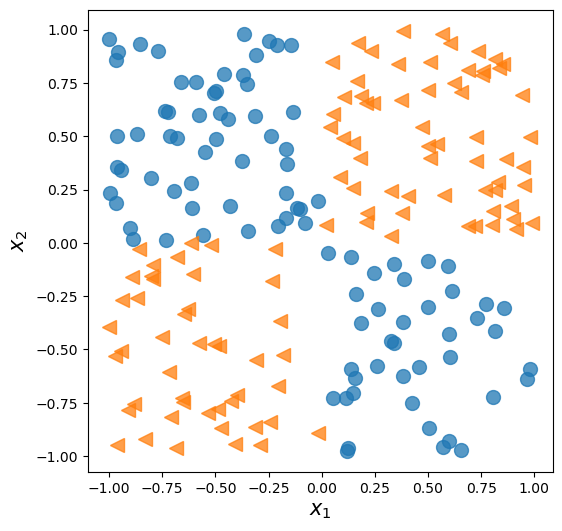

In [17]:
np.random.seed(1)
torch.manual_seed(1)
x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1]<0] = 0

n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype=torch.float32)
y_train = torch.tensor(y[:n_train], dtype=torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)

fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], 
         x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], 
         x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)

plt.show()

Figure 13.2: Scatterplot of training and validation examples 

The code results in the following scatterplot of the training and validation examples, shown with
different markers based on their class label.

In the previous subsection, we covered the essential tools that we need to implement a classifier in
PyTorch. We now need to decide what architecture we should choose for this task and dataset. As
a general rule of thumb, the more layers we have, and the more neurons we have in each layer, the
larger the capacity of the model will be. Here, the model capacity can be thought of as a measure of
how readily the model can approximate complex functions. While having more parameters means
the network can fit more complex functions, larger models are usually harder to train (and prone to
overfitting). In practice, it is always a good idea to start with a simple model as a baseline, for example,
a single-layer NN like logistic regression



In [18]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

After defining the model, we will initialize the cross-entropy loss function for binary classification
and the SGD optimizer

In [19]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Next, we will create a data loader that uses a batch size of 2 for the train data

In [20]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Now we will train the model for 200 epochs and record a history of training epochs

In [21]:
torch.manual_seed(1)
num_epochs = 200
def train(model, num_epochs, train_dl, x_valid, y_valid):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            is_correct = ((pred>=0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.mean()

        loss_hist_train[epoch] /= n_train/batch_size
        accuracy_hist_train[epoch] /= n_train/batch_size

        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] = loss.item()
        is_correct = ((pred>=0.5).float() == y_valid).float()
        accuracy_hist_valid[epoch] += is_correct.mean()
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

history = train(model, num_epochs, train_dl, x_valid, y_valid)

Notice that the history of training epochs includes the train loss and validation loss and the train accuracy
and validation accuracy, which is useful for visual inspection after training. In the following code,
we will plot the learning curves, including the training and validation loss, as well as their accuracies.

The following code will plot the training performance

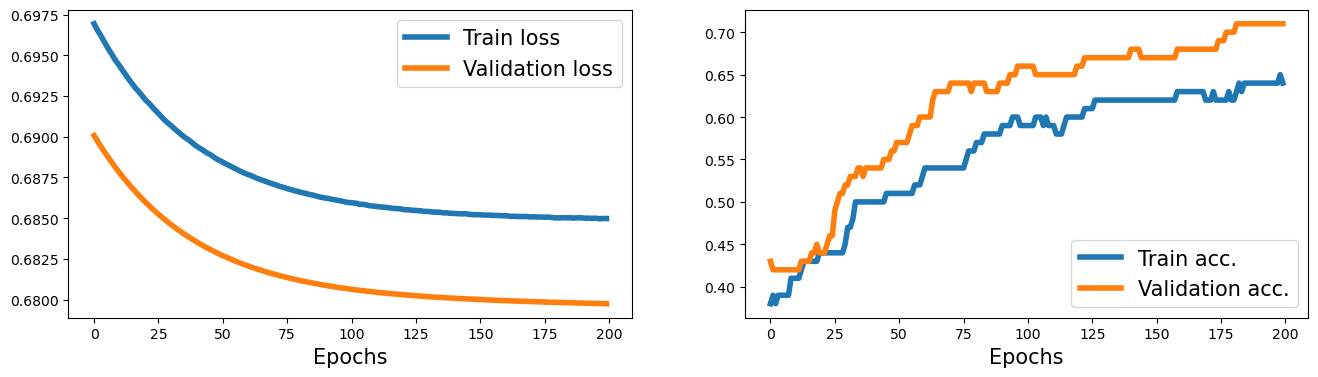

In [22]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
plt.show()

Figure 13.3: Loss and accuracy results

As you can see, a simple model with no hidden layer can only derive a linear decision boundary, which
is unable to solve the XOR problem. As a consequence, we can observe that the loss terms for both the
training and the validation datasets are very high, and the classification accuracy is very low.

To derive a nonlinear decision boundary, we can add one or more hidden layers connected via nonlinear
activation functions. The universal approximation theorem states that a feedforward NN with a single
hidden layer and a relatively large number of hidden units can approximate arbitrary continuous functions
relatively well. Thus, one approach for tackling the XOR problem more satisfactorily is to add a
hidden layer and compare different numbers of hidden units until we observe satisfactory results on
the validation dataset. Adding more hidden units would correspond to increasing the width of a layer.

Alternatively, we can also add more hidden layers, which will make the model deeper. The advantage
of making a network deeper rather than wider is that fewer parameters are required to achieve a
comparable model capacity.

However, a downside of deep (versus wide) models is that deep models are prone to vanishing and
exploding gradients, which make them harder to train.

As an exercise, try adding one, two, three, and four hidden layers, each with four hidden units. In
the following example, we will take a look at the results of a feedforward NN with two hidden layers


In [23]:
model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)
 
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)

model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

We can repeat the previous code for visualization, which produces the following

In [24]:
history = train(model, num_epochs, train_dl, x_valid, y_valid)

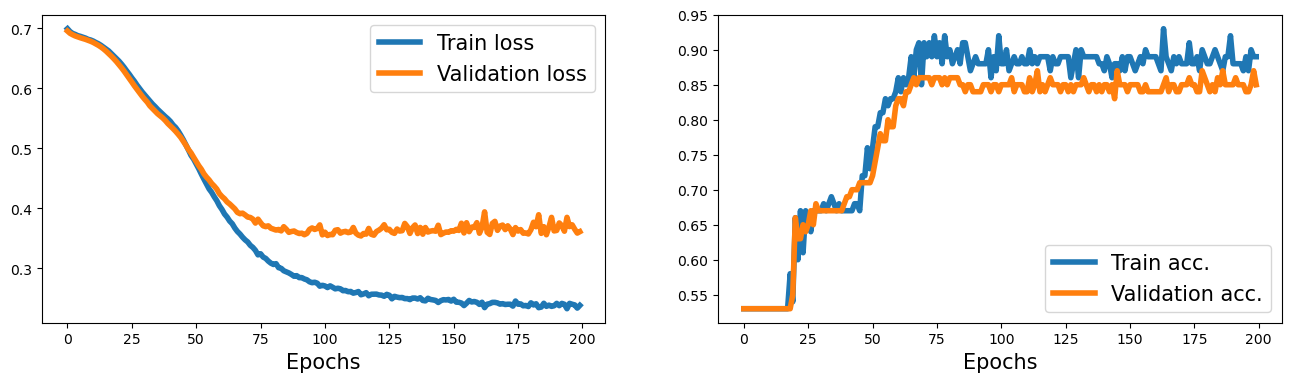

In [25]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
plt.show()

Figure 13.4: Loss and accuracy results after adding two hidden layers

Now, we can see that the model is able to derive a nonlinear decision boundary for this data, and the
model reaches 100 percent accuracy on the training dataset. The validation dataset’s accuracy is 95
percent, which indicates that the model is slightly overfitting.

#### Making model building more flexible with nn.Module

In the previous example, we used the PyTorch Sequential class to create a fully connected NN with
multiple layers. This is a very common and convenient way of building models. However, it unfortunately
doesn’t allow us to create more complex models that have multiple input, output, or intermediate
branches. That’s where nn.Module comes in handy.

The alternative way to build complex models is by subclassing nn.Module. In this approach, we create a
new class derived from nn.Module and define the method, __init__(), as a constructor. The forward()
method is used to specify the forward pass. In the constructor function, __init__(), we define the
layers as attributes of the class so that they can be accessed via the self reference attribute. Then, in
the forward() method, we specify how these layers are to be used in the forward pass of the NN. The
code for defining a new class that implements the previous model is as follows


In [26]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.Sigmoid()
        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        for f in self.module_list:
            x = f(x)
        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred>=0.5).float()
            



Notice that we put all layers in the nn.ModuleList object, which is just a list object composed of
nn.Module items. This makes the code more readable and easier to follow.

Once we define an instance of this new class, we can train it as we did previously

In [27]:
model = MyModule()
model

MyModule(
  (module_list): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [28]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
    
# torch.manual_seed(1)
history = train(model, num_epochs, train_dl, x_valid, y_valid)

Next, besides the train history, we will use the mlxtend library to visualize the validation data and
the decision boundary.

Mlxtend can be installed via conda or pip as follow

In [29]:
# conda install mlxtend -c conda-forge
# !pip install mlxtend

The following code will plot the training performance along with the decision region bias

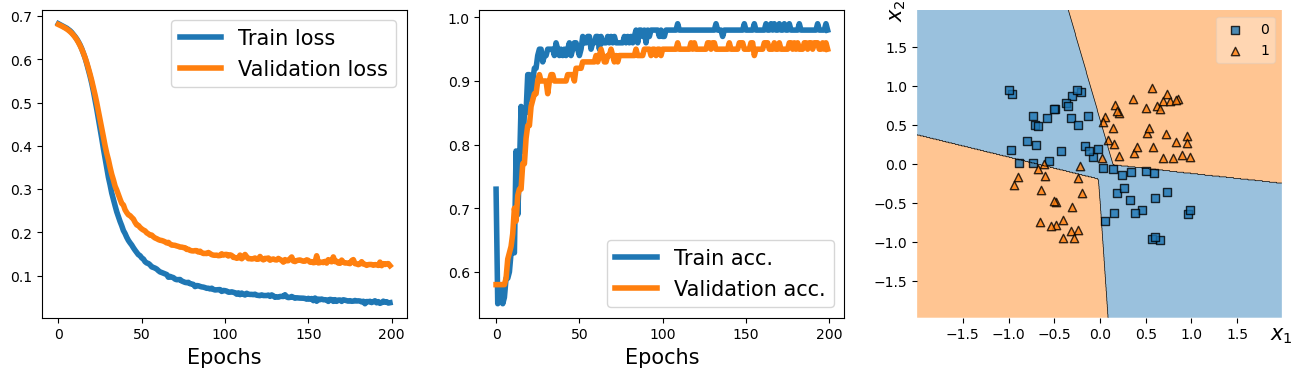

In [30]:
from mlxtend.plotting import plot_decision_regions

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(), 
                      y=y_valid.numpy().astype(np.int64),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)

plt.show()

Figure 13.5: Results, including a scatterplot

This results in Figure 13.5, with three separate panels for the losses, accuracies, and the scatterplot
of the validation examples, along with the decision boundary

#### Writing custom layers in PyTorch

In cases where we want to define a new layer that is not already supported by PyTorch, we can define
a new class derived from the nn.Module class. This is especially useful when designing a new layer or
customizing an existing layer.

To illustrate the concept of implementing custom layers, let’s consider a simple example. Imagine we
want to define a new linear layer that computes $w(x+ \epsilon)+b$ , where 𝜖𝜖 refers to a random variable as a
noise variable. To implement this computation, we define a new class as a subclass of nn.Module. For
this new class, we have to define both the constructor __init__() method and the forward() method.
In the constructor, we define the variables and other required tensors for our customized layer. We
can create variables and initialize them in the constructor if the input_size is given to the constructor.
Alternatively, we can delay the variable initialization (for instance, if we do not know the exact input
shape upfront) and delegate it to another method for late variable creation.

To look at a concrete example, we are going to define a new layer called NoisyLinear, which implements
the computation $w(x+ \epsilon)+b$ , which was mentioned in the preceding paragraph


In [31]:
class NoisyLinear(nn.Module):
    def __init__(self, input_size, output_size, noise_stddev=0.1):
        super().__init__()
        w = torch.Tensor(input_size, output_size)
        self.w = nn.Parameter(w)  # nn.Parameter is a Tensor that's a module parameter.
        nn.init.xavier_uniform_(self.w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            noise = torch.normal(0.0, self.noise_stddev, x.shape)
            x_new = torch.add(x, noise)
        else:
            x_new = x
        return torch.add(torch.mm(x_new, self.w), self.b)   

In the constructor, we have added an argument, noise_stddev, to specify the standard deviation for 
the distribution of 𝜖𝜖, which is sampled from a Gaussian distribution. Furthermore, notice that in the 
forward() method, we have used an additional argument, training=False. We use it to distinguish 
whether the layer is used during training or only for prediction (this is sometimes also called inference) 
or evaluation. Also, there are certain methods that behave differently in training and prediction 
modes. You will encounter an example of such a method, Dropout, in the upcoming chapters. In the 
previous code snippet, we also specified that the random vector, 𝜖𝜖, was to be generated and added to 
the input during training only and not used for inference or evaluation.

Before we go a step further and use our custom NoisyLinear layer in a model, let’s test it in the context 
of a simple example.

1. In the following code, we will define a new instance of this layer, and execute it on an input 
tensor. Then, we will call the layer three times on the same input tensor

In [32]:
torch.manual_seed(1)
noisy_layer = NoisyLinear(4, 2)
 
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=False)) 

tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)


<span style="background-color: #e0e0e0">
Note that the outputs for the first two calls differ because the NoisyLinear layer 
added random noise to the input tensor. The third call outputs [0, 0] as we didn’t 
add noise by specifying training=False.
</span>

2. Now, let’s create a new model similar to the previous one for solving the XOR classification task. 
As before, we will use the nn.Module class for model building, but this time, we will use our 
NoisyLinear layer as the first hidden layer of the multilayer perceptron. The code is as follows

In [33]:
class MyNoisyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = NoisyLinear(2, 4, 0.07)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(4, 4)
        self.a2 = nn.ReLU()
        self.l3 = nn.Linear(4, 1)
        self.a3 = nn.Sigmoid()
        
    def forward(self, x, training=False):
        x = self.l1(x, training)
        x = self.a1(x)
        x = self.l2(x)
        x = self.a2(x)
        x = self.l3(x)
        x = self.a3(x)
        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred>=0.5).float()

torch.manual_seed(1)
model = MyNoisyModule()
model

MyNoisyModule(
  (l1): NoisyLinear()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

3. Similarly, we will train the model as we did previously. At this time, to compute the prediction on the training batch, we use pred = model(x_batch, True)[:, 0] instead of pred = model(x_batch)[:, 0]:

In [34]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.015)
    
torch.manual_seed(1)

loss_hist_train = [0] * num_epochs
accuracy_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
accuracy_hist_valid = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch, True)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train[epoch] += loss.item()
        is_correct = ((pred>=0.5).float() == y_batch).float()
        accuracy_hist_train[epoch] += is_correct.mean()

    loss_hist_train[epoch] /= n_train/batch_size
    accuracy_hist_train[epoch] /= n_train/batch_size

    pred = model(x_valid)[:, 0]
    loss = loss_fn(pred, y_valid)
    loss_hist_valid[epoch] = loss.item()
    is_correct = ((pred>=0.5).float() == y_valid).float()
    accuracy_hist_valid[epoch] += is_correct.mean()

4. After the model is trained, we can plot the losses, accuracies, and the decision boundary

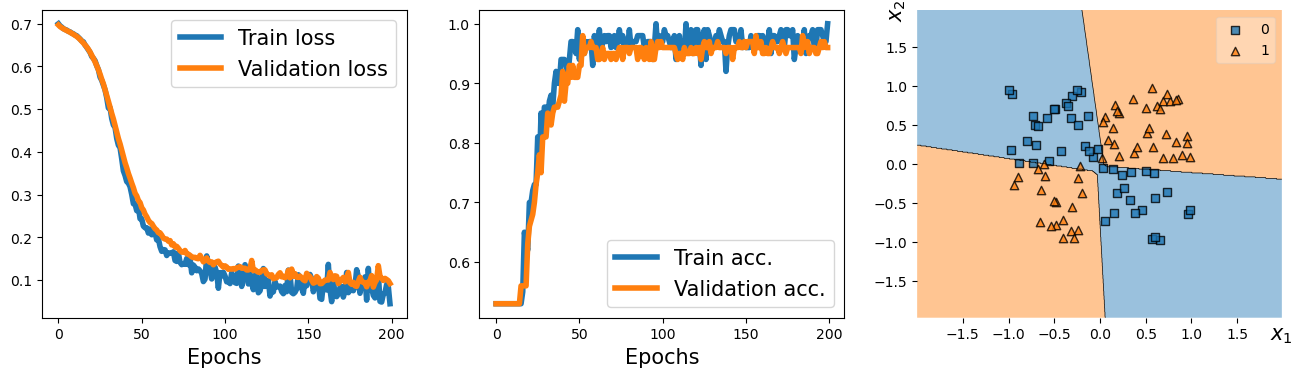

In [35]:
from mlxtend.plotting import plot_decision_regions

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(loss_hist_train, lw=4)
plt.plot(loss_hist_valid, lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(accuracy_hist_train, lw=4)
plt.plot(accuracy_hist_valid, lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(), 
                      y=y_valid.numpy().astype(np.int64),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

Figure 13.6: Results using NoisyLinear as the first hidden layer

Here, our goal was to learn how to define a new custom layer subclassed from nn.Module and to 
use it as we would use any other standard torch.nn layer. Although, with this particular example, 
NoisyLinear did not help to improve the performance, please keep in mind that our objective was 
to mainly learn how to write a customized layer from scratch. In general, writing a new customized 
layer can be useful in other applications, for example, if you develop a new algorithm that depends 
on a new layer beyond the existing ones.

### Project one – predicting the fuel efficiency of a car

So far, in this chapter, we have mostly focused on the torch.nn module. We used nn.Sequential to 
construct the models for simplicity. Then, we made model building more flexible with nn.Module and 
implemented feedforward NNs, to which we added customized layers. In this section, we will work 
on a real-world project of predicting the fuel efficiency of a car in miles per gallon (MPG). We will 
cover the underlying steps in machine learning tasks, such as data preprocessing, feature engineering, 
training, prediction (inference), and evaluation.

#### Working with feature columns

In machine learning and deep learning applications, we can encounter various different types of features: continuous, unordered categorical (nominal), and ordered categorical (ordinal). You will recall 
that in Chapter 4, Building Good Training Datasets – Data Preprocessing, we covered different types of 
features and learned how to handle each type. Note that while numeric data can be either continuous 
or discrete, in the context of machine learning with PyTorch, “numeric” data specifically refers to 
continuous data of floating point type.

Sometimes, feature sets are comprised of a mixture of different feature types. For example, consider 
a scenario with a set of seven different features, as shown in Figure 13.7

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch13/figures/13_07.png" width=800 />

Figure 13.7 Auto MPG data structure

The features shown in the figure (model year, cylinders, displacement, horsepower, weight, acceleration, and origin) were obtained from the Auto MPG dataset, which is a common machine learning 
benchmark dataset for predicting the fuel efficiency of a car in MPG. The full dataset and its description are available from UCI’s machine learning repository at https://archive.ics.uci.edu/ml/datasets/auto+mpg.

We are going to treat five features from the Auto MPG dataset (number of cylinders, displacement, 
horsepower, weight, and acceleration) as “numeric” (here, continuous) features. The model year 
can be regarded as an ordered categorical (ordinal) feature. Lastly, the manufacturing origin can be 
regarded as an unordered categorical (nominal) feature with three possible discrete values, 1, 2, and 
3, which correspond to the US, Europe, and Japan, respectively.

Let’s first load the data and apply the necessary preprocessing steps, including dropping the incomplete 
rows, partitioning the dataset into training and test datasets, as well as standardizing the continuous 
features

In [36]:
import pandas as pd
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv(url, names=column_names,
                 na_values = "?", comment='\t',
                 sep=" ", skipinitialspace=True)

df.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [37]:
print(df.isna().sum())

df = df.dropna()
df = df.reset_index(drop=True)
df.tail()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
387,27.0,4,140.0,86.0,2790.0,15.6,82,1
388,44.0,4,97.0,52.0,2130.0,24.6,82,2
389,32.0,4,135.0,84.0,2295.0,11.6,82,1
390,28.0,4,120.0,79.0,2625.0,18.6,82,1
391,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [38]:
import sklearn
import sklearn.model_selection


df_train, df_test = sklearn.model_selection.train_test_split(df, train_size=0.8, random_state=1)
train_stats = df_train.describe().transpose()
train_stats

,count,mean,std,min,25%,50%,75%,max
MPG,313.0,23.404153,7.666909,9.0,17.5,23.0,29.0,46.6
Cylinders,313.0,5.402556,1.701506,3.0,4.0,4.0,8.0,8.0
Displacement,313.0,189.512780,102.675646,68.0,104.0,140.0,260.0,455.0
Horsepower,313.0,102.929712,37.919046,46.0,75.0,92.0,120.0,230.0
Weight,313.0,2961.198083,848.602146,1613.0,2219.0,2755.0,3574.0,5140.0
Acceleration,313.0,15.704473,2.725399,8.5,14.0,15.5,17.3,24.8
Model Year,313.0,75.929712,3.675305,70.0,73.0,76.0,79.0,82.0
Origin,313.0,1.591054,0.807923,1.0,1.0,1.0,2.0,3.0


In [39]:
from packaging import version


numeric_column_names = ['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration']

df_train_norm, df_test_norm = df_train.copy(), df_test.copy()


if version.parse(pd.__version__) >= version.parse("2.0.0"):

    for col_name in numeric_column_names:
        mean = train_stats.loc[col_name, 'mean']
        std = train_stats.loc[col_name, 'std']
        df_train_norm[col_name] = (df_train_norm[col_name] - mean) / std
        df_test_norm[col_name] = (df_test_norm[col_name] - mean) / std

else:

    for col_name in numeric_column_names:
        mean = train_stats.loc[col_name, 'mean']
        std  = train_stats.loc[col_name, 'std']
        df_train_norm.loc[:, col_name] = (df_train_norm.loc[:, col_name] - mean) / std
        df_test_norm.loc[:, col_name] = (df_test_norm.loc[:, col_name] - mean) / std
        
df_train_norm.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
203,28.0,-0.824303,-0.901020,-0.736562,-0.950031,0.255202,76,3
255,19.4,0.351127,0.413800,-0.340982,0.293190,0.548737,78,1
72,13.0,1.526556,1.144256,0.713897,1.339617,-0.625403,72,1
235,30.5,-0.824303,-0.891280,-1.053025,-1.072585,0.475353,77,1
37,14.0,1.526556,1.563051,1.636916,1.470420,-1.359240,71,1


Figure 13.8: Preprocessed Auto MG data

The pandas DataFrame that we created via the previous code snippet contains five columns with values 
of the type float. These columns will constitute the continuous features.

Next, let’s group the rather fine-grained model year (ModelYear) information into buckets to simplify 
the learning task for the model that we are going to train later. Concretely, we are going to assign each 
car into one of four year buckets, as follows:
$$
\text{bucket} = \begin{cases}
0 \;\; \text{if year} \lt 73 \\
1 \;\; \text {if} \; 73 \le \text{year} \lt 76 \\
2 \;\; \text {if} \; 76 \le \text{year} \lt 79 \\
3 \;\; \text {if} \; \text{year} \ge 79 
\end{cases}
$$
Note that the chosen intervals were selected arbitrarily to illustrate the concepts of “bucketing.” In 
order to group the cars into these buckets, we will first define three cut-off values: [73, 76, 79] for the 
model year feature. These cut-off values are used to specify half-closed intervals, for instance, (–∞, 73), 
[73, 76), [76, 79), and [76, ∞). Then, the original numeric features will be passed to the torch.bucketize
function (https://pytorch.org/docs/stable/generated/torch.bucketize.html) to generate the 
indices of the buckets. The code is as follows

In [40]:
boundaries = torch.tensor([73, 76, 79])
 
v = torch.tensor(df_train_norm['Model Year'].values)
df_train_norm['Model Year Bucketed'] = torch.bucketize(v, boundaries, right=True)

v = torch.tensor(df_test_norm['Model Year'].values)
df_test_norm['Model Year Bucketed'] = torch.bucketize(v, boundaries, right=True)

numeric_column_names.append('Model Year Bucketed')

We added this bucketized feature column to the Python list numeric_column_names.

Next, we will proceed with defining a list for the unordered categorical feature, Origin. In PyTorch, 
There are two ways to work with a categorical feature: using an embedding layer via nn.Embedding
(https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html), or using one-hot-encoded vectors (also called indicator). In the encoding approach, for example, index 0 will be encoded 
as [1, 0, 0], index 1 will be encoded as [0, 1, 0], and so on. On the other hand, the embedding layer 
maps each index to a vector of random numbers of the type float, which can be trained. (You can 
think of the embedding layer as a more efficient implementation of a one-hot encoding multiplied 
with a trainable weight matrix.)

When the number of categories is large, using the embedding layer with fewer dimensions than the 
number of categories can improve the performance.

In the following code snippet, we will use the one-hot-encoding approach on the categorical feature 
in order to convert it into the dense format

In [41]:
from torch.nn.functional import one_hot

total_origin = len(set(df_train_norm['Origin']))

origin_encoded = one_hot(torch.from_numpy(df_train_norm['Origin'].values) % total_origin)
x_train_numeric = torch.tensor(df_train_norm[numeric_column_names].values)
x_train = torch.cat([x_train_numeric, origin_encoded], 1).float()
 
origin_encoded = one_hot(torch.from_numpy(df_test_norm['Origin'].values) % total_origin)
x_test_numeric = torch.tensor(df_test_norm[numeric_column_names].values)
x_test = torch.cat([x_test_numeric, origin_encoded], 1).float()


After encoding the categorical feature into a three-dimensional dense feature, we concatenated it with 
the numeric features we processed in the previous step. Finally, we will create the label tensors from 
the ground truth MPG values as follows

In [42]:
y_train = torch.tensor(df_train_norm['MPG'].values).float()
y_test = torch.tensor(df_test_norm['MPG'].values).float()

In this section, we have covered the most common approaches for preprocessing and creating features in PyTorch.
    
#### Training a DNN regression model

Now, after constructing the mandatory features and labels, we will create a data loader that uses a 
batch size of 8 for the train data

In [43]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(x_train, y_train)
batch_size = 8
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

Next, we will build a model with two fully connected layers where one has 8 hidden units and another 
has 4.

In [44]:
hidden_units = [8, 4]
input_size = x_train.shape[1]

all_layers = []
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit

all_layers.append(nn.Linear(hidden_units[-1], 1))

model = nn.Sequential(*all_layers)

model

Sequential(
  (0): Linear(in_features=9, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)

After defining the model, we will define the MSE loss function for regression and use stochastic gradient descent for optimization

In [45]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Now we will train the model for 200 epochs and display the train loss for every 20 epochs

In [46]:
torch.manual_seed(1)
num_epochs = 200
log_epochs = 20 
for epoch in range(num_epochs):
    loss_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist_train += loss.item()
    if epoch % log_epochs==0:
        print(f'Epoch {epoch}  Loss {loss_hist_train/len(train_dl):.4f}')
 

Epoch 0  Loss 536.1047
Epoch 20  Loss 8.4361
Epoch 40  Loss 7.8695
Epoch 60  Loss 7.1891
Epoch 80  Loss 6.7062
Epoch 100  Loss 6.7599
Epoch 120  Loss 6.3124
Epoch 140  Loss 6.6864
Epoch 160  Loss 6.7648
Epoch 180  Loss 6.2156


After 200 epochs, the train loss was around 5. We can now evaluate the regression performance of the 
trained model on the test dataset. To predict the target values on new data points, we can feed their 
features to the model:

In [47]:
with torch.no_grad():
    pred = model(x_test.float())[:, 0]
    loss = loss_fn(pred, y_test)
    print(f'Test MSE: {loss.item():.4f}')
    print(f'Test MAE: {nn.L1Loss()(pred, y_test).item():.4f}')

Test MSE: 9.6133
Test MAE: 2.1211


The MSE on the test set is 9.6, and the mean absolute error (MAE) is 2.1. After this regression project, 
we will work on a classification project in the next section.

### Project two – classifying MNIST handwritten digits

For this classification project, we are going to categorize MNIST handwritten digits. In the previous 
section, we covered the four essential steps for machine learning in PyTorch in detail, which we will 
need to repeat in this section.

You will recall that in Chapter 12 you learned the way of loading available datasets from the torchvision
module. First, we are going to load the MNIST dataset using the torchvision module.

1. The setup step includes loading the dataset and specifying hyperparameters (the size of the 
train set and test set, and the size of mini-batches):

In [48]:
import torchvision 
from torchvision import transforms 

image_path = './'
transform = transforms.Compose([transforms.ToTensor()])

mnist_train_dataset = torchvision.datasets.MNIST(root=image_path, 
                                           train=True, 
                                           transform=transform, 
                                           download=True)
mnist_test_dataset = torchvision.datasets.MNIST(root=image_path, 
                                           train=False, 
                                           transform=transform, 
                                           download=False)
 
batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset, batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 112kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 949kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.96MB/s]


Here, we constructed a data loader with batches of 64 samples. Next, we will preprocess the 
loaded datasets.

2. We preprocess the input features and the labels. The features in this project are the pixels 
of the images we read from Step 1. We defined a custom transformation using torchvision.
transforms.Compose. In this simple case, our transformation consisted only of one method, 
ToTensor(). The ToTensor() method converts the pixel features into a floating type tensor 
and also normalizes the pixels from the [0, 255] to [0, 1] range. In Chapter 14, Classifying Images with Deep Convolutional Neural Networks, we will see some additional data transformation 
methods when we work with more complex image datasets. The labels are integers from 0 to 
9 representing ten digits. Hence, we don’t need to do any scaling or further conversion. Note 
that we can access the raw pixels using the data attribute, and don’t forget to scale them to 
the range [0, 1].

We will construct the model in the next step once the data is preprocessed

3. Construct the NN model:

In [49]:
hidden_units = [32, 16]
image_size = mnist_train_dataset[0][0].shape
input_size = image_size[0] * image_size[1] * image_size[2]

all_layers = [nn.Flatten()]
for hidden_unit in hidden_units:
    layer = nn.Linear(input_size, hidden_unit)
    all_layers.append(layer)
    all_layers.append(nn.ReLU())
    input_size = hidden_unit

all_layers.append(nn.Linear(hidden_units[-1], 10))
model = nn.Sequential(*all_layers)

model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Linear(in_features=16, out_features=10, bias=True)
)

Note that the model starts with a flatten layer that flattens an input image into 
a one-dimensional tensor. This is because the input images are in the shape of 
[1, 28, 28]. The model has two hidden layers, with 32 and 16 units respectively. 
And it ends with an output layer of ten units representing ten classes, activated 
by a softmax function. In the next step, we will train the model on the train set 
and evaluate it on the test set.

4. Use the model for training, evaluation, and prediction

In [50]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

torch.manual_seed(1)
num_epochs = 20
for epoch in range(num_epochs):
    accuracy_hist_train = 0
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist_train += is_correct.sum()
    accuracy_hist_train /= len(train_dl.dataset)
    print(f'Epoch {epoch}  Accuracy {accuracy_hist_train:.4f}')

Epoch 0  Accuracy 0.8531
Epoch 1  Accuracy 0.9287
Epoch 2  Accuracy 0.9413
Epoch 3  Accuracy 0.9506
Epoch 4  Accuracy 0.9558
Epoch 5  Accuracy 0.9592
Epoch 6  Accuracy 0.9627
Epoch 7  Accuracy 0.9650
Epoch 8  Accuracy 0.9674
Epoch 9  Accuracy 0.9690
Epoch 10  Accuracy 0.9710
Epoch 11  Accuracy 0.9729
Epoch 12  Accuracy 0.9739
Epoch 13  Accuracy 0.9750
Epoch 14  Accuracy 0.9764
Epoch 15  Accuracy 0.9777
Epoch 16  Accuracy 0.9779
Epoch 17  Accuracy 0.9798
Epoch 18  Accuracy 0.9807
Epoch 19  Accuracy 0.9813


We used the cross-entropy loss function for multiclass classification and the Adam optimizer 
for gradient descent. We will talk about the Adam optimizer in Chapter 14. We trained the model 
for 20 epochs and displayed the train accuracy for every epoch. The trained model reached an 
accuracy of 96.3 percent on the training set and we will evaluate it on the testing set

In [51]:
pred = model(mnist_test_dataset.data / 255.)
is_correct = (torch.argmax(pred, dim=1) == mnist_test_dataset.targets).float()
print(f'Test accuracy: {is_correct.mean():.4f}')  

Test accuracy: 0.9653


The test accuracy is 95.6 percent. You have learned how to solve a classification problem using PyTorch.

See [1] for the rest of Chapter 13 regrading PyTorch-Lightning and TensorBoard.

### Reference

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  [Book github.](https://github.com/rasbt/machine-learning-book)



<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>